In [14]:
import json
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from scipy.interpolate import griddata
from pathlib import Path

plt.rcParams.update({
    "figure.facecolor": "#0e1117",
    "axes.facecolor": "#1a1d23",
    "axes.edgecolor": "#444",
    "axes.labelcolor": "#ccc",
    "text.color": "#ccc",
    "xtick.color": "#999",
    "ytick.color": "#999",
    "grid.color": "#333",
    "grid.alpha": 0.4,
    "font.family": "monospace",
    "font.size": 11,
})

results_path = Path("bo_runs/bo_results.json")
with open(results_path) as f:
    results = json.load(f)

ok = [r for r in results if r.get("status") == "success"]
eps = np.array([r["epsilons"] for r in ok])
scores = np.array([r["objective"] for r in ok])
rR = np.array([r["radial_ratio"] for r in ok])
eval_ids = np.array([r["eval_id"] for r in ok])
n_initial = 10  # Sobol phase size

print(f"{len(ok)}/{len(results)} runs  |  "
      f"inside: {(scores > 0.5).sum()}  |  "
      f"outside: {(scores <= 0.5).sum()}  |  "
      f"best r/R: {rR.min():.3f}")

3/3 runs  |  inside: 2  |  outside: 1  |  best r/R: 0.335


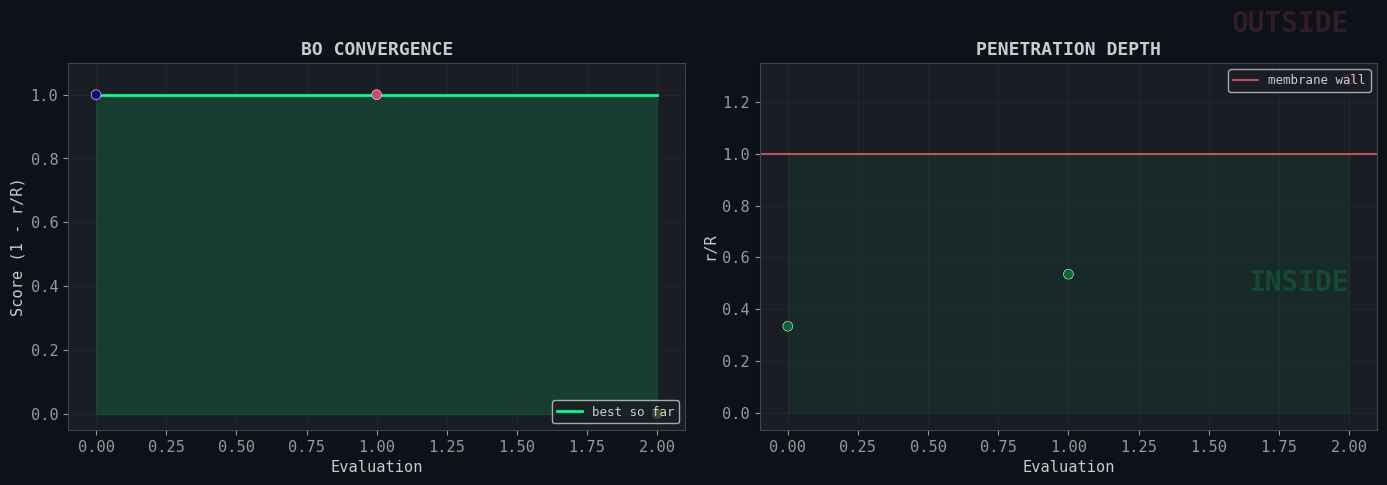

In [15]:
# 1. EXPLORATION TRAJECTORY
# How does BO move through epsilon space over time?
# Trail shows the path, color shifts from blue (early) to yellow (late)

fig = plt.figure(figsize=(14, 5))

# Left: cumulative best + individual scores with trail
ax1 = fig.add_subplot(121)
cum_best = np.maximum.accumulate(scores)

# Color by evaluation order
colors_time = plt.cm.plasma(np.linspace(0, 1, len(eval_ids)))
ax1.fill_between(eval_ids, 0, cum_best, alpha=0.15, color="#00ff88")
ax1.plot(eval_ids, cum_best, color="#00ff88", lw=2, label="best so far")
ax1.scatter(eval_ids, scores, c=np.arange(len(scores)), cmap="plasma",
            s=50, zorder=5, edgecolors="white", linewidths=0.4)

if len(eval_ids) > n_initial:
    ax1.axvline(n_initial - 0.5, color="#ff6b6b", ls="--", alpha=0.6)
    ax1.text(n_initial - 0.5, 1.02, "SOBOL | BO", ha="center",
             fontsize=8, color="#ff6b6b")

ax1.set_xlabel("Evaluation")
ax1.set_ylabel("Score (1 - r/R)")
ax1.set_title("BO CONVERGENCE", fontweight="bold", fontsize=13)
ax1.set_ylim(-0.05, 1.1)
ax1.legend(loc="lower right", fontsize=9)
ax1.grid(True)

# Right: r/R over time — shows how deep the MP gets
ax2 = fig.add_subplot(122)
ax2.scatter(eval_ids, rR, c=scores, cmap="RdYlGn", s=50,
            edgecolors="white", linewidths=0.4, vmin=0, vmax=1)
ax2.axhline(1.0, color="#ff6b6b", ls="-", lw=1.5, alpha=0.7, label="membrane wall")
ax2.fill_between(eval_ids[[0, -1]], 0, 1, alpha=0.06, color="#00ff88")
ax2.text(eval_ids[-1], 0.5, "INSIDE", ha="right", va="center",
         fontsize=20, color="#00ff88", alpha=0.15, fontweight="bold")
ax2.text(eval_ids[-1], 1.5, "OUTSIDE", ha="right", va="center",
         fontsize=20, color="#ff6b6b", alpha=0.15, fontweight="bold")

ax2.set_xlabel("Evaluation")
ax2.set_ylabel("r/R")
ax2.set_title("PENETRATION DEPTH", fontweight="bold", fontsize=13)
ax2.legend(loc="upper right", fontsize=9)
ax2.grid(True)

plt.tight_layout()
plt.show()

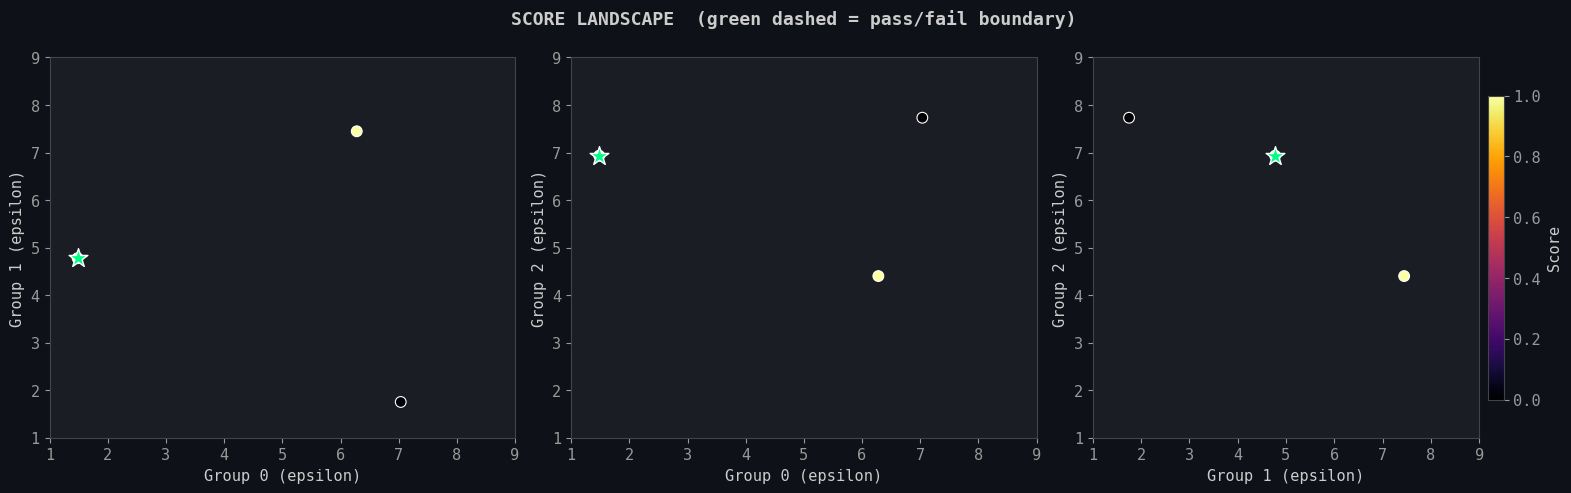

In [16]:
# 2. HEATMAPS: interpolated score landscape in epsilon space
# Shows WHERE in parameter space endocytosis happens

pairs = [(0, 1, "Group 0", "Group 1"),
         (0, 2, "Group 0", "Group 2"),
         (1, 2, "Group 1", "Group 2")]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (i, j, li, lj) in zip(axes, pairs):
    xi = np.linspace(1, 9, 80)
    yi = np.linspace(1, 9, 80)
    XI, YI = np.meshgrid(xi, yi)

    if len(scores) >= 4:
        ZI = griddata(eps[:, [i, j]], scores, (XI, YI), method="cubic", fill_value=0)
        ZI = np.clip(ZI, 0, 1)
        im = ax.contourf(XI, YI, ZI, levels=20, cmap="inferno", vmin=0, vmax=1)
        ax.contour(XI, YI, ZI, levels=[0.5], colors=["#00ff88"], linewidths=2, linestyles="--")

    ax.scatter(eps[:, i], eps[:, j], c=scores, cmap="inferno",
              s=60, edgecolors="white", linewidths=0.8, vmin=0, vmax=1, zorder=5)

    # Mark the best run
    best = np.argmax(scores)
    ax.scatter(eps[best, i], eps[best, j], marker="*", s=200,
              color="#00ff88", edgecolors="white", linewidths=1, zorder=6)

    ax.set_xlabel(f"{li} (epsilon)")
    ax.set_ylabel(f"{lj} (epsilon)")
    ax.set_xlim(1, 9)
    ax.set_ylim(1, 9)

fig.colorbar(plt.cm.ScalarMappable(cmap="inferno", norm=plt.Normalize(0, 1)),
             ax=axes[-1], label="Score", shrink=0.8, pad=0.02)
fig.suptitle("SCORE LANDSCAPE  (green dashed = pass/fail boundary)",
             fontweight="bold", fontsize=13)
plt.tight_layout()
plt.show()

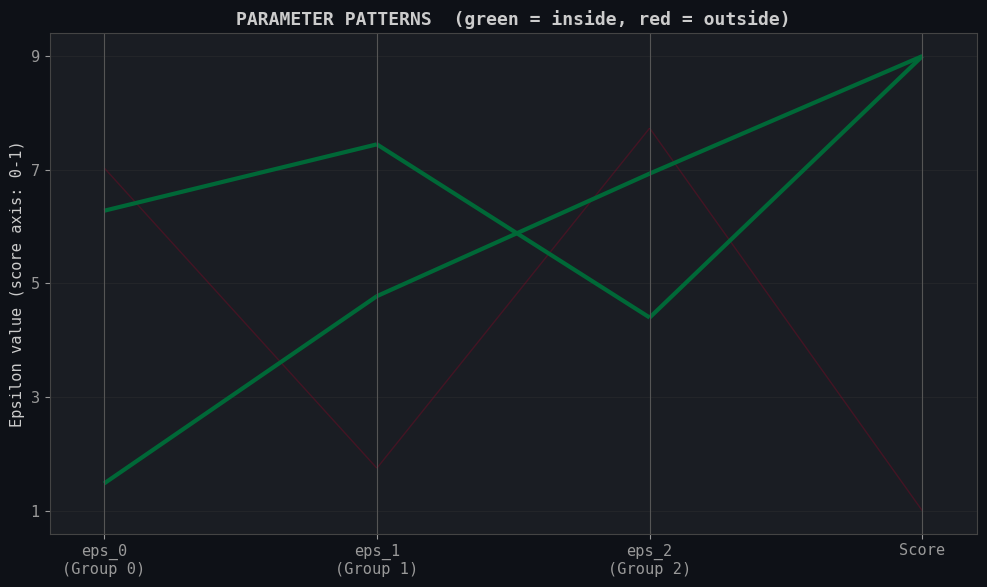

In [17]:
# 3. PARALLEL COORDINATES
# Each line = one run, passing through eps_0, eps_1, eps_2
# Color = score. Shows which PATTERNS of epsilons work.

fig, ax = plt.subplots(figsize=(10, 6))

x_coords = [0, 1, 2, 3]  # eps_0, eps_1, eps_2, score
x_labels = ["eps_0\n(Group 0)", "eps_1\n(Group 1)", "eps_2\n(Group 2)", "Score"]

# Normalize each axis to [0, 1] for display
data = np.column_stack([eps, scores])
mins = np.array([1, 1, 1, 0], dtype=float)
maxs = np.array([9, 9, 9, 1], dtype=float)
normed = (data - mins) / (maxs - mins)

# Sort by score so high scores draw on top
order = np.argsort(scores)

for idx in order:
    y = normed[idx]
    points = np.column_stack([x_coords, y]).reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)

    color = plt.cm.RdYlGn(scores[idx])
    alpha = 0.3 + 0.7 * scores[idx]  # failed runs more transparent
    lw = 1.0 + 2.0 * scores[idx]

    lc = LineCollection(segments, colors=[color], alpha=alpha, linewidths=lw)
    ax.add_collection(lc)

# Axis decorations
for x in x_coords:
    ax.axvline(x, color="#555", lw=0.8)

ax.set_xticks(x_coords)
ax.set_xticklabels(x_labels)
ax.set_xlim(-0.2, 3.2)
ax.set_ylim(-0.05, 1.05)

# Y-axis tick labels showing actual values
yticks = np.linspace(0, 1, 5)
ax.set_yticks(yticks)
ax.set_yticklabels([f"{v:.0f}" for v in np.linspace(1, 9, 5)])
ax.set_ylabel("Epsilon value (score axis: 0-1)")

ax.set_title("PARAMETER PATTERNS  (green = inside, red = outside)",
             fontweight="bold", fontsize=13)
ax.grid(True, axis="y")
plt.tight_layout()
plt.show()

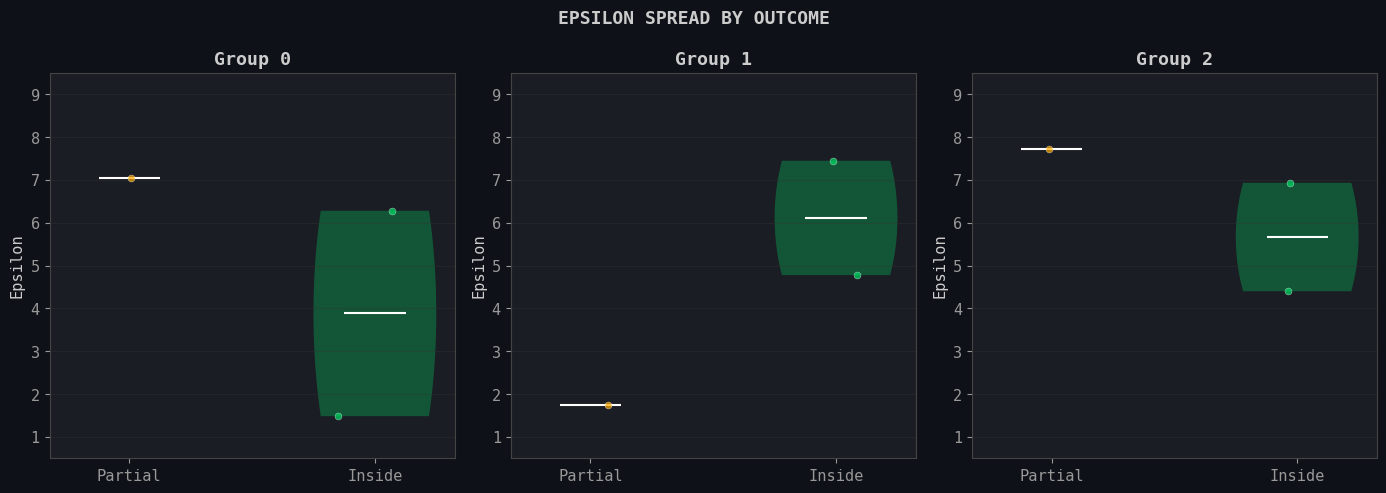

In [18]:
# 4. EPSILON SPREADS: violin + strip for inside vs outside
# Shows the DISTRIBUTION of what works vs what doesn't

inside = scores > 0.0  # any penetration at all
deep = scores > 0.5    # clearly inside

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
group_names = ["Group 0", "Group 1", "Group 2"]

for i, ax in enumerate(axes):
    categories = []
    data_cat = []

    if (~inside).sum() > 0:
        categories.append("Outside")
        data_cat.append(eps[~inside, i])
    if (inside & ~deep).sum() > 0:
        categories.append("Partial")
        data_cat.append(eps[inside & ~deep, i])
    if deep.sum() > 0:
        categories.append("Inside")
        data_cat.append(eps[deep, i])

    colors_cat = {"Outside": "#ff4444", "Partial": "#ffaa00", "Inside": "#00dd66"}
    positions = list(range(len(categories)))

    if len(data_cat) > 0:
        parts = ax.violinplot(data_cat, positions=positions, showmedians=True,
                              showextrema=False)
        for pc, cat in zip(parts["bodies"], categories):
            pc.set_facecolor(colors_cat[cat])
            pc.set_alpha(0.3)
        parts["cmedians"].set_color("white")

        # Strip plot (jittered dots)
        for pos, cat, d in zip(positions, categories, data_cat):
            jitter = np.random.normal(0, 0.06, len(d))
            ax.scatter(pos + jitter, d, c=colors_cat[cat], s=25,
                      alpha=0.7, edgecolors="white", linewidths=0.3, zorder=5)

    ax.set_xticks(positions)
    ax.set_xticklabels(categories)
    ax.set_ylabel("Epsilon")
    ax.set_ylim(0.5, 9.5)
    ax.set_title(group_names[i], fontweight="bold")
    ax.grid(True, axis="y")

fig.suptitle("EPSILON SPREAD BY OUTCOME", fontweight="bold", fontsize=13)
plt.tight_layout()
plt.show()

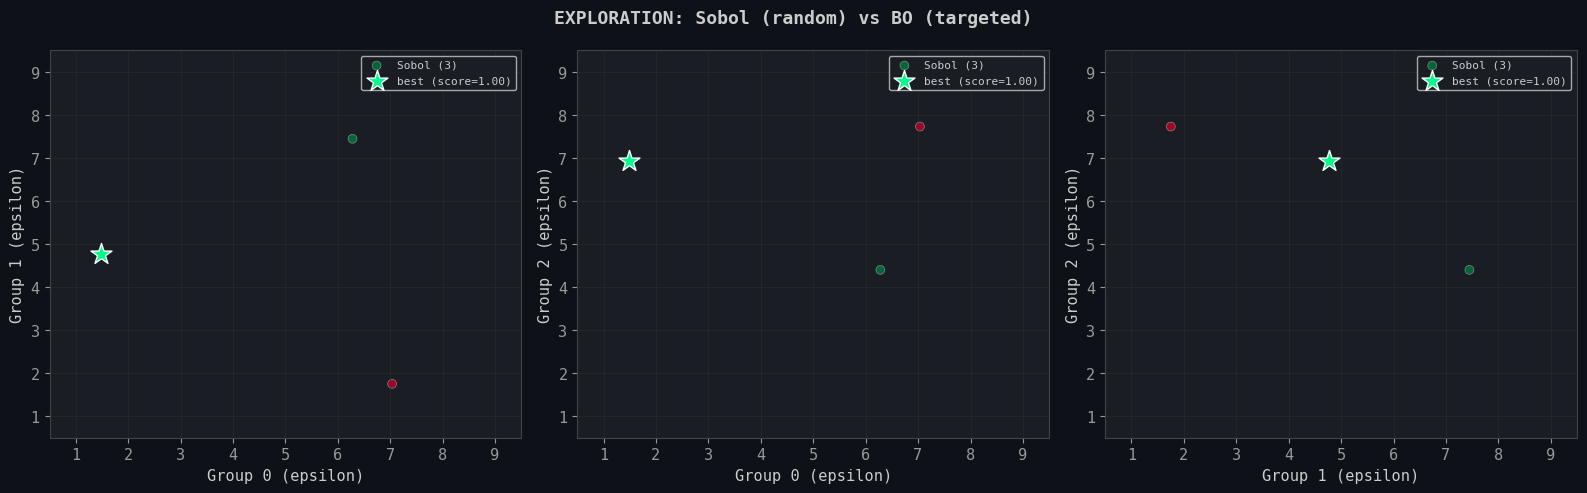

In [19]:
# 5. SAMPLING STRATEGY: where is BO choosing to explore?
# Shows Sobol (uniform) vs BO (targeted) sampling in epsilon space

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
pair_idx = [(0, 1), (0, 2), (1, 2)]
pair_names = [("Group 0", "Group 1"), ("Group 0", "Group 2"), ("Group 1", "Group 2")]

sobol_mask = eval_ids < n_initial
bo_mask = eval_ids >= n_initial

for ax, (i, j), (ni, nj) in zip(axes, pair_idx, pair_names):
    # Sobol samples: circles
    if sobol_mask.sum() > 0:
        ax.scatter(eps[sobol_mask, i], eps[sobol_mask, j],
                  c=scores[sobol_mask], cmap="RdYlGn", vmin=0, vmax=1,
                  s=40, marker="o", edgecolors="#888", linewidths=0.5,
                  label=f"Sobol ({sobol_mask.sum()})")

    # BO samples: diamonds, connected by trail
    if bo_mask.sum() > 1:
        bo_eps_i = eps[bo_mask, i]
        bo_eps_j = eps[bo_mask, j]
        ax.plot(bo_eps_i, bo_eps_j, color="#666", lw=0.8, alpha=0.5, zorder=3)
        ax.scatter(bo_eps_i, bo_eps_j,
                  c=scores[bo_mask], cmap="RdYlGn", vmin=0, vmax=1,
                  s=70, marker="D", edgecolors="white", linewidths=0.8,
                  label=f"BO ({bo_mask.sum()})", zorder=4)
    elif bo_mask.sum() == 1:
        ax.scatter(eps[bo_mask, i], eps[bo_mask, j],
                  c=scores[bo_mask], cmap="RdYlGn", vmin=0, vmax=1,
                  s=70, marker="D", edgecolors="white", linewidths=0.8,
                  label=f"BO ({bo_mask.sum()})", zorder=4)

    # Star on best
    best = np.argmax(scores)
    ax.scatter(eps[best, i], eps[best, j], marker="*", s=250,
              color="#00ff88", edgecolors="white", linewidths=1, zorder=6,
              label=f"best (score={scores[best]:.2f})")

    ax.set_xlabel(f"{ni} (epsilon)")
    ax.set_ylabel(f"{nj} (epsilon)")
    ax.set_xlim(0.5, 9.5)
    ax.set_ylim(0.5, 9.5)
    ax.legend(fontsize=8, loc="upper right")
    ax.grid(True)

fig.suptitle("EXPLORATION: Sobol (random) vs BO (targeted)",
             fontweight="bold", fontsize=13)
plt.tight_layout()
plt.show()

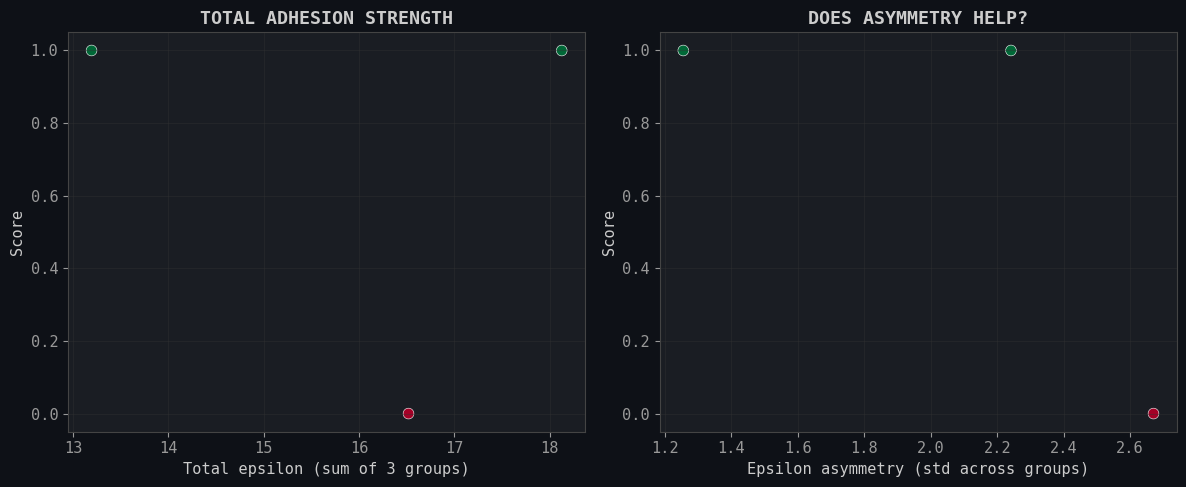

In [20]:
# 6. TOTAL EPSILON vs OUTCOME
# Is it the total adhesion strength that matters, or the pattern?

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

eps_total = eps.sum(axis=1)
eps_std = eps.std(axis=1)  # asymmetry: how different are the 3 groups?

# Total epsilon vs score
sc = ax1.scatter(eps_total, scores, c=scores, cmap="RdYlGn",
                 s=60, edgecolors="white", linewidths=0.4, vmin=0, vmax=1)
ax1.set_xlabel("Total epsilon (sum of 3 groups)")
ax1.set_ylabel("Score")
ax1.set_title("TOTAL ADHESION STRENGTH", fontweight="bold")
ax1.grid(True)

# Asymmetry vs score
ax2.scatter(eps_std, scores, c=scores, cmap="RdYlGn",
            s=60, edgecolors="white", linewidths=0.4, vmin=0, vmax=1)
ax2.set_xlabel("Epsilon asymmetry (std across groups)")
ax2.set_ylabel("Score")
ax2.set_title("DOES ASYMMETRY HELP?", fontweight="bold")
ax2.grid(True)

plt.tight_layout()
plt.show()